# Swarm Data Analysis

## Datasets

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats

plt.style.use("seaborn-v0_8-whitegrid")

optimized = pd.read_csv("swarm_foraging_experiment_optimized_20260507_180038.csv")
hypothesis = pd.read_csv("swarm_foraging_experiment_hypothesized_20260507_180038.csv")

cols_to_drop = [
    "iteration", "width", "height", "n_food_clusters", 
    "food_area_percentage", "food_base_quantity", "num_agents", 
    "pheromone_decay_rate", "safety_buffer_steps", "foraging_start_threshold", 
    "pheromone_base_drop", "pheromone_follow_prob", "food_richness_memory_regulator", "seed"
]

optimized = optimized.drop(columns=cols_to_drop, errors='ignore')
hypothesis = hypothesis.drop(columns=cols_to_drop, errors='ignore')

display(optimized.head())
display(hypothesis.head())

C:\Users\tasio\AppData\Local\Temp\ipykernel_13524\1626036128.py:9: DtypeWarning: Columns (0: Has Food) have mixed types. Specify dtype option on import or set low_memory=False.
  optimized = pd.read_csv("swarm_foraging_experiment_optimized_20260507_180038.csv")
C:\Users\tasio\AppData\Local\Temp\ipykernel_13524\1626036128.py:10: DtypeWarning: Columns (0: Has Food) have mixed types. Specify dtype option on import or set low_memory=False.
  hypothesis = pd.read_csv("swarm_foraging_experiment_hypothesized_20260507_180038.csv")


,RunId,Step,Foraging,Returning,Resting,Alive,Dead (Energy),Dead (Temperature),Deaths Foraging (Energy),Deaths Foraging (Temperature),...,Mean Distance to Nest,Mean Lifetime Food Collected,AgentID,Energy,Temperature,State,Distance_to_Nest,Age,Lifetime Food Collected,Has Food
0,0,0.0,40,0,0,40,0,0,0,0,...,0.0,0.0,1.0,1000.0,30.0,State.FORAGING,0.0,0.0,0.0,False
1,0,0.0,40,0,0,40,0,0,0,0,...,0.0,0.0,2.0,1000.0,30.0,State.FORAGING,0.0,0.0,0.0,False
2,0,0.0,40,0,0,40,0,0,0,0,...,0.0,0.0,3.0,1000.0,30.0,State.FORAGING,0.0,0.0,0.0,False
3,0,0.0,40,0,0,40,0,0,0,0,...,0.0,0.0,4.0,1000.0,30.0,State.FORAGING,0.0,0.0,0.0,False
4,0,0.0,40,0,0,40,0,0,0,0,...,0.0,0.0,5.0,1000.0,30.0,State.FORAGING,0.0,0.0,0.0,False


,RunId,Step,Foraging,Returning,Resting,Alive,Dead (Energy),Dead (Temperature),Deaths Foraging (Energy),Deaths Foraging (Temperature),...,Mean Distance to Nest,Mean Lifetime Food Collected,AgentID,Energy,Temperature,State,Distance_to_Nest,Age,Lifetime Food Collected,Has Food
0,0,0.0,50,0,0,50,0,0,0,0,...,0.0,0.0,1.0,1000.0,30.0,State.FORAGING,0.0,0.0,0.0,False
1,0,0.0,50,0,0,50,0,0,0,0,...,0.0,0.0,2.0,1000.0,30.0,State.FORAGING,0.0,0.0,0.0,False
2,0,0.0,50,0,0,50,0,0,0,0,...,0.0,0.0,3.0,1000.0,30.0,State.FORAGING,0.0,0.0,0.0,False
3,0,0.0,50,0,0,50,0,0,0,0,...,0.0,0.0,4.0,1000.0,30.0,State.FORAGING,0.0,0.0,0.0,False
4,0,0.0,50,0,0,50,0,0,0,0,...,0.0,0.0,5.0,1000.0,30.0,State.FORAGING,0.0,0.0,0.0,False


In [24]:
def process_swarm_data(df, name):
    print(f"--- Processing Dataset: {name} ---")
    step_keys = ["RunId", "Step"] 
    
    step_df = (
        df.drop_duplicates(step_keys)
        .sort_values(step_keys)
        .copy()
        .reset_index(drop=True)
    )
    step_df["Step"] = step_df["Step"].astype(int)

    # Final State of each Run
    run_df = step_df.groupby("RunId", as_index=False).tail(1).copy().reset_index(drop=True)
    run_df["completed_steps"] = run_df["Step"] + 1
    
    # Food ratio 
    run_df["food_collection_ratio"] = run_df["Total Food Collected"] / (
        run_df["Total Food Collected"] + run_df["Remaining Food (Units)"].clip(lower=1.0)
    )

    rows_per_run = df.groupby("RunId").size().rename("rows")
    steps_per_run = step_df.groupby("RunId")["Step"].nunique().rename("unique_steps")
    
    cols_to_keep = [
        "RunId", "completed_steps", "Alive", "Dead (Energy)", "Dead (Temperature)",
        "Total Food Collected", "Remaining Food (Units)", "Resource Retrieval Rate",
        "Load Gini", "Cumulative Thermal Load", "Shannon Entropy", "Thermal Efficiency",
        "Mean Agent Energy", "Mean Agent Temperature", "Mean Distance to Nest",
        "Mean Lifetime Food Collected"
    ]
    
    run_summary = (
        run_df[[c for c in cols_to_keep if c in run_df.columns]]
        .merge(rows_per_run, on="RunId")
        .merge(steps_per_run, on="RunId")
        .sort_values("RunId")
        .reset_index(drop=True)
    )

    print(f"- Runs represented: {run_summary['RunId'].nunique():,}")
    print(f"- Mean completed steps: {run_summary['completed_steps'].mean():,.2f}")
    print()

    stats_cols = ["completed_steps", "Total Food Collected", "Resource Retrieval Rate", "Load Gini", "Thermal Efficiency", "Shannon Entropy"]
    summary_stats = run_summary[[c for c in stats_cols if c in run_summary.columns]].describe().T
    
    display(summary_stats)
    return run_summary, summary_stats

optimized_summary, optimized_stats = process_swarm_data(optimized, "Optimized")
hypothesis_summary, hypothesis_stats = process_swarm_data(hypothesis, "Hypothesis")

--- Processing Dataset: Optimized ---
- Runs represented: 30
- Mean completed steps: 1,751.80



,count,mean,std,min,25%,50%,75%,max
completed_steps,30.0,1751.800000,1209.454947,453.000000,979.750000,1337.000000,2418.250000,5118.000000
Total Food Collected,30.0,758.266667,555.209928,87.000000,370.000000,643.000000,978.750000,2287.000000
Resource Retrieval Rate,30.0,0.473615,0.291074,0.168932,0.265832,0.389725,0.603972,1.489362
Load Gini,30.0,0.320505,0.122414,0.063200,0.256667,0.330946,0.372307,0.558108
Thermal Efficiency,30.0,0.006198,0.003493,0.001160,0.003643,0.005046,0.008651,0.015260
Shannon Entropy,30.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


--- Processing Dataset: Hypothesis ---
- Runs represented: 30
- Mean completed steps: 503.27



,count,mean,std,min,25%,50%,75%,max
completed_steps,30.0,503.266667,427.998383,195.000000,271.250000,336.500000,496.750000,1840.000000
Total Food Collected,30.0,326.466667,348.749958,26.000000,84.250000,171.000000,444.000000,1425.000000
Resource Retrieval Rate,30.0,0.571493,0.324346,0.126829,0.293439,0.511603,0.828216,1.183206
Load Gini,30.0,0.307993,0.145210,0.103333,0.176386,0.298393,0.374966,0.647692
Thermal Efficiency,30.0,0.002647,0.002166,0.000273,0.000898,0.001900,0.004327,0.008194
Shannon Entropy,30.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


As can be seen the mean completed_steps value of 1,751.80, which is nearly three and a half times higher than the Hypothesis group’s 503.27. This indicates that the Optuna-tuned parameters were highly effective at preventing the premature mass extinction events that plagued the baseline configuration.

An important contrast appears in the Resource Retrieval Rate. The Hypothesis group achieved a higher mean retrieval rate of 0.571 compared to 0.473 for the Optimized group. However, in the context of swarm survival, a higher rate does not necessarily equate to superior long-term performance. Instead, it highlights a high-intensity "burn fast" strategy wherein agents forage aggressively and collect resources rapidly, but at the cost of a drastically shortened collective lifespan. The Optimized group adopts a slower, more sustainable strategy, while the per-step retrieval occurs at a lower rate, the swarm survives substantially longer and ultimately collects more than double the total food overall (758.27 units versus 326.47 units).

The Thermal Efficiency metric heavily supports the superiority of this sustainable approach. The recorded values appear numerically miniscule (0.006198 for Optimized and 0.002647 for Hypothesis) because the Cumulative Thermal Load aggregates heat across all agents and all simulation ticks, resulting in a massive denominator. However, despite the seemingly small absolute numbers, the relative improvement is profound: the Optimized swarm is approximately 134% more thermally efficient. In a simulated environment where heat accumulation acts as a hard physical constraint, this demonstrates that the tuned swarm produces significantly more useful work (food collected) per unit of dangerous thermal load generated.

Finally, the Shannon Entropy values of 0.0000 across all summaries are best interpreted as an artifact of the final-state recording methodology. Because the data represents the terminal step of each run, the swarms had already collapsed and agents had died, leaving no meaningful spatial diversity to measure. Conversely, the Load Gini values remain relatively stable and equitable across both groups (0.320 for Optimized and 0.308 for Hypothesis), suggesting that the underlying task distribution mechanism functions consistently regardless of how long the swarm actually survives.

## Survival Analysis

--- Survival Analysis: Optimized ---
- Agents observed (total pool): 1,200
- Mean lifetime: 611.4 steps
- Median lifetime: 479.5 steps
- Min / max lifetime: 117 / 5,117 steps
- Kaplan-Meier median survival time: 479 steps
- Death causes by model counters: 33.8% energy, 66.2% temperature



,last_state,agents,percent
0,State.RETURNING,1077,89.75
1,State.RESTING,66,5.50
2,State.FORAGING,57,4.75




--- Survival Analysis: Hypothesis ---
- Agents observed (total pool): 1,500
- Mean lifetime: 248.7 steps
- Median lifetime: 211.0 steps
- Min / max lifetime: 112 / 1,839 steps
- Kaplan-Meier median survival time: 211 steps
- Death causes by model counters: 34.8% energy, 65.2% temperature



,last_state,agents,percent
0,State.RETURNING,1268,84.533333
1,State.FORAGING,119,7.933333
2,State.RESTING,113,7.533333


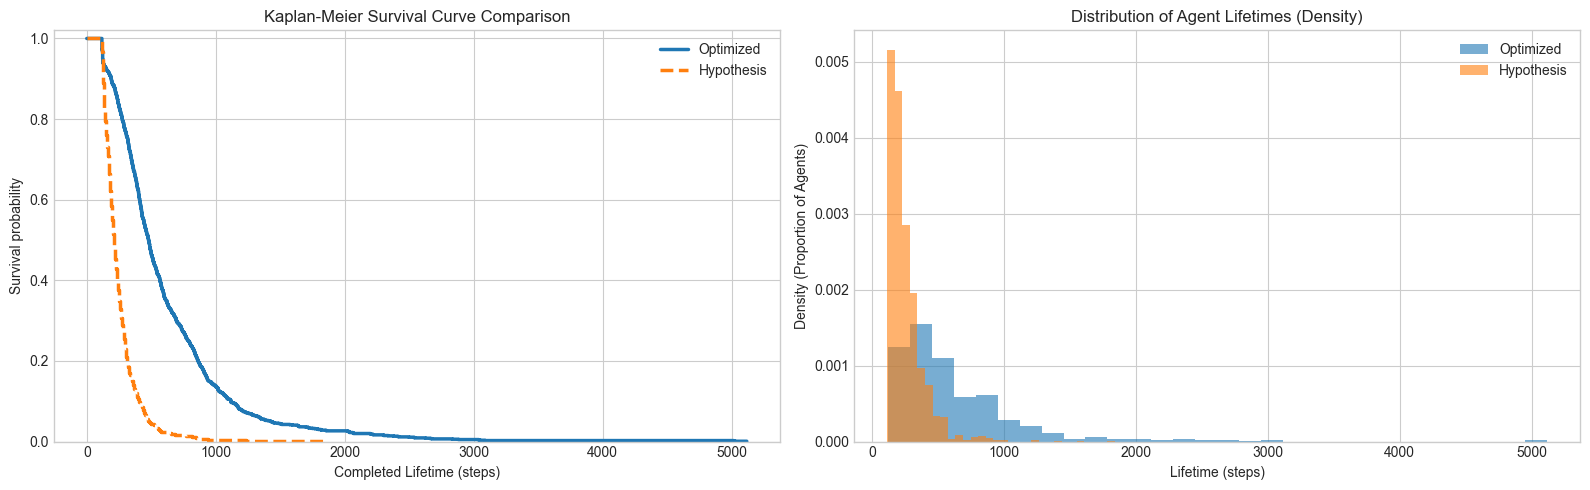

In [25]:
def analyze_agent_survival(df, dataset_name):
    print(f"--- Survival Analysis: {dataset_name} ---")
    
    agent_last_index = df.groupby(["RunId", "AgentID"])['Step'].idxmax()
    last_agent_rows = df.loc[agent_last_index].copy().reset_index(drop=True)
    last_agent_rows["lifetime_steps"] = last_agent_rows["Step"].astype(int) + 1

    agent_lifetimes = last_agent_rows[["RunId", "AgentID", "lifetime_steps", "State", "Temperature", "Energy", "Has Food", "Distance_to_Nest"]].copy()

    life_counts = agent_lifetimes["lifetime_steps"].value_counts().sort_index()
    km_times = []
    km_survival = []
    n_at_risk = int(agent_lifetimes.shape[0])
    survival_probability = 1.0
    
    for time_step, event_count in life_counts.items():
        if n_at_risk <= 0:
            break
        survival_probability *= 1.0 - (event_count / n_at_risk)
        km_times.append(int(time_step))
        km_survival.append(float(survival_probability))
        n_at_risk -= int(event_count)

    km_curve = pd.DataFrame({"time": km_times, "survival_probability": km_survival})
    median_survival = next((time for time, survival in zip(km_times, km_survival) if survival <= 0.5), None)

    cause_counts = last_agent_rows["State"].value_counts().rename_axis("last_state").reset_index(name="agents")
    state_percent = cause_counts.copy()
    state_percent["percent"] = 100.0 * state_percent["agents"] / state_percent["agents"].sum()

    run_df = df.groupby("RunId").tail(1)
    final_death_summary = run_df[["Dead (Energy)", "Dead (Temperature)"]].sum()
    total_deaths = float(final_death_summary.sum())
    energy_share = 100.0 * final_death_summary["Dead (Energy)"] / max(total_deaths, 1.0)
    temp_share = 100.0 * final_death_summary["Dead (Temperature)"] / max(total_deaths, 1.0)

    print(f"- Agents observed (total pool): {len(agent_lifetimes):,}")
    print(f"- Mean lifetime: {agent_lifetimes['lifetime_steps'].mean():,.1f} steps")
    print(f"- Median lifetime: {agent_lifetimes['lifetime_steps'].median():,.1f} steps")
    print(f"- Min / max lifetime: {agent_lifetimes['lifetime_steps'].min():,} / {agent_lifetimes['lifetime_steps'].max():,} steps")
    
    if median_survival is not None:
        print(f"- Kaplan-Meier median survival time: {median_survival:,} steps")
    else:
        print("- Kaplan-Meier median survival time was not reached.")
        
    print(f"- Death causes by model counters: {energy_share:.1f}% energy, {temp_share:.1f}% temperature")
    print()
    display(state_percent)
    print("\n" + "="*50 + "\n")
    
    return km_curve, agent_lifetimes

km_opt, lifetimes_opt = analyze_agent_survival(optimized, "Optimized")
km_hyp, lifetimes_hyp = analyze_agent_survival(hypothesis, "Hypothesis")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Kaplan-Meier Curve Comparison
ax1.step([0, *km_opt['time']], [1.0, *km_opt['survival_probability']], where="post", linewidth=2.5, label="Optimized")
ax1.step([0, *km_hyp['time']], [1.0, *km_hyp['survival_probability']], where="post", linewidth=2.5, label="Hypothesis", linestyle="--")
ax1.set_title("Kaplan-Meier Survival Curve Comparison")
ax1.set_xlabel("Completed Lifetime (steps)")
ax1.set_ylabel("Survival probability")
ax1.set_ylim(0, 1.02)
ax1.legend()

# Lifetime Distribution Histogram Comparison
ax2.hist(lifetimes_opt["lifetime_steps"], bins=30, alpha=0.6, label="Optimized", density=True, color="#1f77b4")
ax2.hist(lifetimes_hyp["lifetime_steps"], bins=30, alpha=0.6, label="Hypothesis", density=True, color="#ff7f0e")
ax2.set_title("Distribution of Agent Lifetimes (Density)")
ax2.set_xlabel("Lifetime (steps)")
ax2.set_ylabel("Density (Proportion of Agents)")
ax2.legend()

plt.tight_layout()
plt.show()

Here Kaplan-Meier survival curves were employed alongside a terminal state distribution analysis. The Kaplan-Meier estimator is a non-parametric statistic used to measure the fraction of subjects living past a certain amount of time, providing a visual and mathematical representation of survivability. The terminal state analysis categorizes the exact physiological cause (energy vs. temperature) and behavioral state (Foraging, Returning, Resting) of the agents at their moment of death.

The Kaplan-Meier analysis reveals a drastic improvement in the survivability of the Optimized cohort. The median survival time for the Optimized agents reached 479 steps, more than doubling the 211 steps observed in the Hypothesis group. This behavioral divergence is distinctly visible in the survival curve plot: the Hypothesis curve (dashed orange) collapses sharply, with almost the entire population failing before step 1,000. In stark contrast, the Optimized curve (solid blue) exhibits a pronounced, heavy survival tail, with some agents successfully managing their resources to remain active beyond 5,000 steps.

Additionaly, the mortality attribution results challenge initial assumptions about how the Optuna parameters extended life. Unlike what one might expect, the primary physiological cause of death remained nearly identical between the two groups. Thermal death (T >= T_crit) accounted for 66.2% of fatalities in the Optimized configuration and 65.2% in the Hypothesis configuration. This indicates that the optimized parameters did not entirely "solve" or eliminate thermal overload. Rather, they fundamentally delayed it. The Optimized agents still ultimately die of heatstroke, but their calibrated safety buffers and foraging thresholds allow them to endure many more successful foraging cycles before the environment finally overwhelms them.

Furthermore, the behavioral state at the time of death highlights a systemic bottleneck in the environment: the "Returning Death Trap." In the Hypothesis configuration, 84.5% of agents died while in the RETURNING state. Surprisingly, this phenomenon is even more pronounced in the Optimized configuration, where 89.7% of deaths occurred during the return journey. This bottleneck is a direct consequence of how agents perceive and calculate their own survivability via the internal _project_danger mechanisms. By design, they are on the  edge of their physical limits.

Ultimately, the optimization did not shift deaths to the RESTING or FORAGING states, but it rather maximized the agents' ability to repeatedly survive the outgoing trip. Because they are programmed to forage until their projections warn of imminent death, when the environment's math finally outpaces their safety buffers, the failure occurs almost exclusively during that perilous, mathematically unforgiving return phase.

## Mission Progression and System Dynamics

--- Mission Progression: Optimized ---
- Avg survival ratio: 0.349
- Avg resource retrieval rate: 0.953
- Avg Shannon entropy: 0.638
- Avg thermal efficiency: 0.01704



,phase,survival_ratio,food_collection_ratio,resource_retrieval_rate,mean_agent_energy,mean_agent_temperature,mean_distance_to_nest,shannon_entropy,thermal_efficiency,load_gini,share_foraging,share_returning,share_resting,share_has_food
0,0-20%,0.843913,0.037686,1.866110,812.186416,33.879405,3.415436,0.717416,0.050440,0.190087,0.500931,0.266916,0.232153,0.259067
1,20-40%,0.481120,0.069185,1.055897,700.665185,35.228754,4.386012,0.805996,0.010798,0.224833,0.498583,0.275622,0.225796,0.260020
2,40-60%,0.236905,0.081618,0.765904,701.387353,35.040509,4.140848,0.736499,0.008549,0.270400,0.465078,0.296590,0.238333,0.280712
3,60-80%,0.130602,0.088006,0.596527,702.463462,34.993309,4.378144,0.601769,0.007891,0.302081,0.450884,0.309276,0.239841,0.294939
4,80-100%,0.051985,0.091039,0.479646,586.587064,37.656045,5.500614,0.326373,0.007503,0.319860,0.516849,0.299085,0.181212,0.256146




--- Mission Progression: Hypothesis ---
- Avg survival ratio: 0.494
- Avg resource retrieval rate: 1.491
- Avg Shannon entropy: 0.581
- Avg thermal efficiency: 0.02318



,phase,survival_ratio,food_collection_ratio,resource_retrieval_rate,mean_agent_energy,mean_agent_temperature,mean_distance_to_nest,shannon_entropy,thermal_efficiency,load_gini,share_foraging,share_returning,share_resting,share_has_food
0,0-20%,0.981722,0.025220,2.909178,879.507771,33.551120,2.337762,0.655114,0.091957,0.236982,0.639483,0.199072,0.161444,0.192919
1,20-40%,0.775964,0.047244,1.681237,667.662392,39.927267,3.078107,0.748028,0.010062,0.222623,0.682129,0.194895,0.122976,0.154268
2,40-60%,0.470567,0.054570,1.220375,588.615791,42.375752,2.919574,0.664385,0.005185,0.226406,0.648186,0.226879,0.124936,0.140348
3,60-80%,0.192731,0.056747,0.917825,557.905648,43.162381,2.587497,0.566102,0.004263,0.244291,0.574531,0.260309,0.165160,0.142323
4,80-100%,0.048747,0.057404,0.722710,451.835044,45.067936,2.488107,0.273607,0.004067,0.253749,0.591610,0.280992,0.117480,0.115654


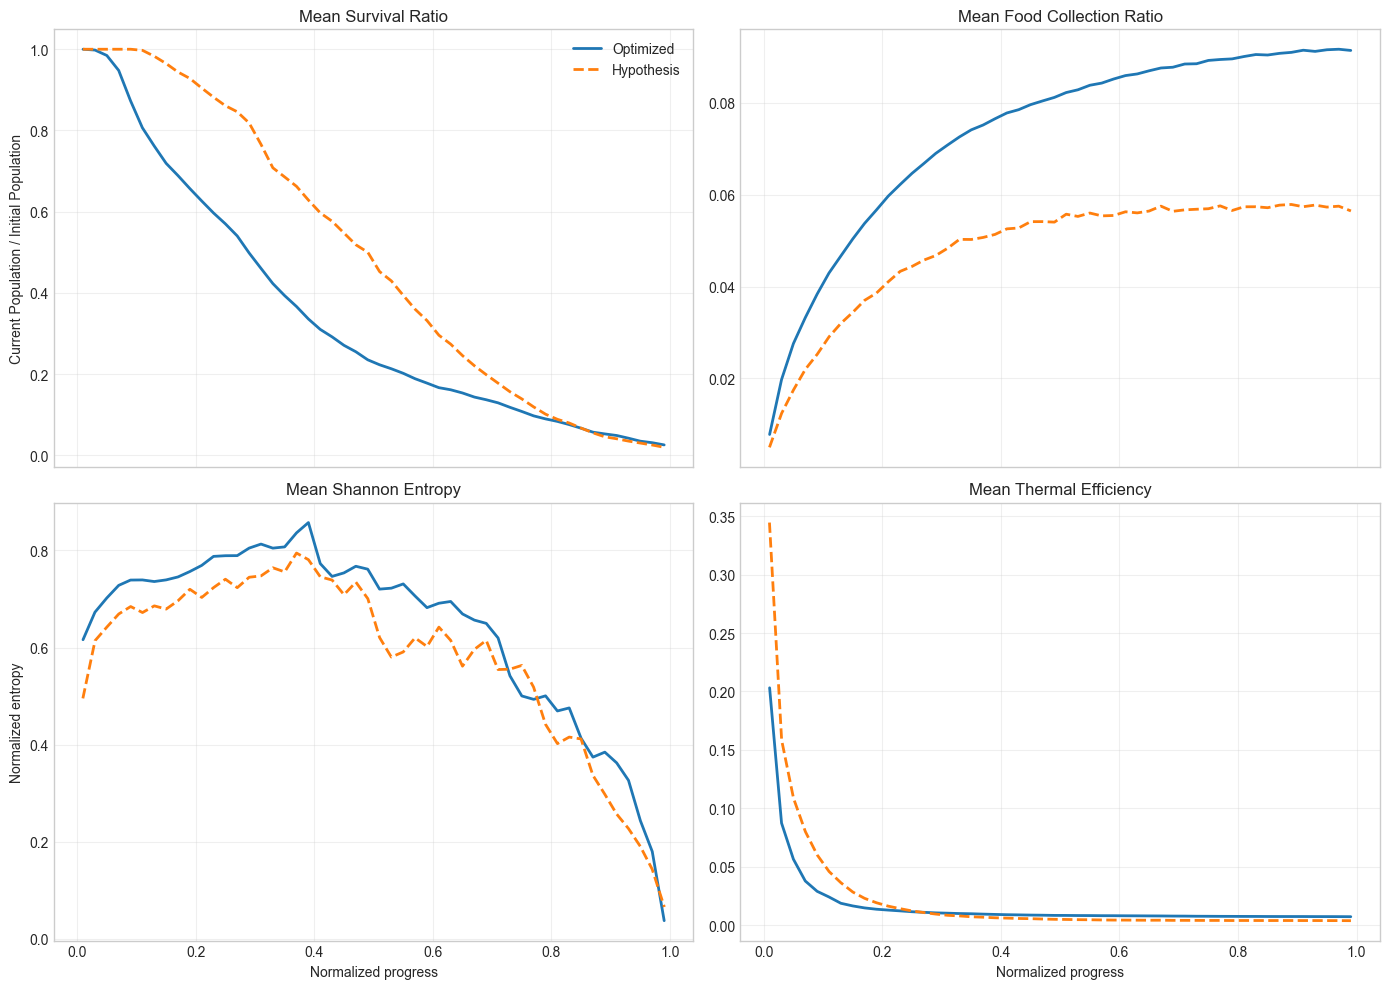

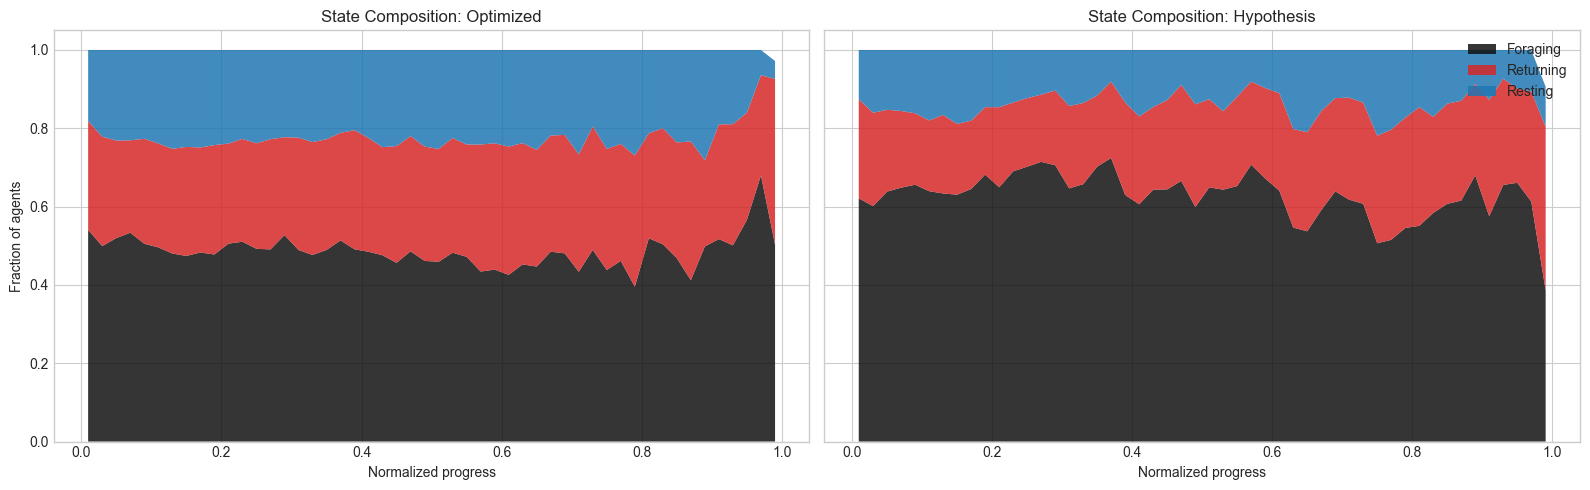

In [26]:
def process_mission_progression(df, dataset_name):
    print(f"--- Mission Progression: {dataset_name} ---")
    
    # Work on a copy to avoid SettingWithCopy warnings
    df = df.copy()
    
    # State identification - FIXED to handle Enum string representation
    state_str = df["State"].astype(str)
    df["is_foraging"] = state_str.str.contains("FORAGING").astype(int)
    df["is_returning"] = state_str.str.contains("RETURNING").astype(int)
    df["is_resting"] = state_str.str.contains("RESTING").astype(int)
    df["has_food_int"] = df["Has Food"].fillna(False).astype(bool).astype(int)

    # 1. Step-level aggregations
    step_summary = (
        df.groupby(["RunId", "Step"], as_index=False)
        .agg(
            num_agents=("AgentID", "size"),
            alive=("Alive", "first"),
            total_food_collected=("Total Food Collected", "first"),
            remaining_food_units=("Remaining Food (Units)", "first"),
            resource_retrieval_rate=("Resource Retrieval Rate", "first"),
            load_gini=("Load Gini", "first"),
            cumulative_thermal_load=("Cumulative Thermal Load", "first"),
            shannon_entropy=("Shannon Entropy", "first"),
            thermal_efficiency=("Thermal Efficiency", "first"),
            mean_agent_energy=("Energy", "mean"),
            mean_agent_temperature=("Temperature", "mean"),
            mean_distance_to_nest=("Distance_to_Nest", "mean"),
            mean_lifetime_food_collected=("Lifetime Food Collected", "mean"),
            share_foraging=("is_foraging", "mean"),
            share_returning=("is_returning", "mean"),
            share_resting=("is_resting", "mean"),
            share_has_food=("has_food_int", "mean"),
        )
        .sort_values(["RunId", "Step"])
        .reset_index(drop=True)
    )
    
    initial_population = step_summary.groupby("RunId")["alive"].transform("max")
    step_summary["survival_ratio"] = step_summary["alive"] / initial_population
    
    step_summary["food_collection_ratio"] = step_summary["total_food_collected"] / (
        step_summary["total_food_collected"] + step_summary["remaining_food_units"].clip(lower=1.0)
    )
    
    step_summary["normalized_progress"] = step_summary["Step"] / step_summary.groupby("RunId")["Step"].transform("max")
    
    step_summary["phase"] = pd.cut(
        step_summary["normalized_progress"],
        bins=np.linspace(0.0, 1.0, 6),
        labels=["0-20%", "20-40%", "40-60%", "60-80%", "80-100%"],
        include_lowest=True,
    )

    phase_means = (
        step_summary.groupby("phase", observed=False)
        .agg(
            survival_ratio=("survival_ratio", "mean"),
            food_collection_ratio=("food_collection_ratio", "mean"),
            resource_retrieval_rate=("resource_retrieval_rate", "mean"),
            mean_agent_energy=("mean_agent_energy", "mean"),
            mean_agent_temperature=("mean_agent_temperature", "mean"),
            mean_distance_to_nest=("mean_distance_to_nest", "mean"),
            shannon_entropy=("shannon_entropy", "mean"),
            thermal_efficiency=("thermal_efficiency", "mean"),
            load_gini=("load_gini", "mean"),
            share_foraging=("share_foraging", "mean"),
            share_returning=("share_returning", "mean"),
            share_resting=("share_resting", "mean"),
            share_has_food=("share_has_food", "mean"),
        )
        .reset_index()
    )

    progress_bins = np.linspace(0.0, 1.0, 51)
    step_summary["progress_bin"] = pd.cut(step_summary["normalized_progress"], bins=progress_bins, labels=False, include_lowest=True)
    
    progress_curves = (
        step_summary.dropna(subset=["progress_bin"])
        .groupby("progress_bin", observed=True)
        .agg(
            progress_center=("normalized_progress", "mean"),
            survival_ratio=("survival_ratio", "mean"),
            food_collection_ratio=("food_collection_ratio", "mean"),
            resource_retrieval_rate=("resource_retrieval_rate", "mean"),
            shannon_entropy=("shannon_entropy", "mean"),
            thermal_efficiency=("thermal_efficiency", "mean"),
            share_foraging=("share_foraging", "mean"),
            share_returning=("share_returning", "mean"),
            share_resting=("share_resting", "mean"),
        )
        .reset_index(drop=True)
    )

    # Summaries
    print(f"- Avg survival ratio: {step_summary['survival_ratio'].mean():.3f}")
    print(f"- Avg resource retrieval rate: {step_summary['resource_retrieval_rate'].mean():.3f}")
    print(f"- Avg Shannon entropy: {step_summary['shannon_entropy'].mean():.3f}")
    print(f"- Avg thermal efficiency: {step_summary['thermal_efficiency'].mean():.5f}")
    print()
    display(phase_means)
    print("\n" + "="*50 + "\n")
    
    return phase_means, progress_curves

phase_opt, prog_opt = process_mission_progression(optimized, "Optimized")
phase_hyp, prog_hyp = process_mission_progression(hypothesis, "Hypothesis")

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

# Survival Ratio
axes[0, 0].plot(prog_opt["progress_center"], prog_opt["survival_ratio"], color="#1f77b4", linewidth=2, label="Optimized")
axes[0, 0].plot(prog_hyp["progress_center"], prog_hyp["survival_ratio"], color="#ff7f0e", linewidth=2, linestyle="--", label="Hypothesis")
axes[0, 0].set_title("Mean Survival Ratio")
axes[0, 0].set_ylabel("Current Population / Initial Population")
axes[0, 0].legend()

# Food Collection Ratio
axes[0, 1].plot(prog_opt["progress_center"], prog_opt["food_collection_ratio"], color="#1f77b4", linewidth=2)
axes[0, 1].plot(prog_hyp["progress_center"], prog_hyp["food_collection_ratio"], color="#ff7f0e", linewidth=2, linestyle="--")
axes[0, 1].set_title("Mean Food Collection Ratio")

# Shannon Entropy
axes[1, 0].plot(prog_opt["progress_center"], prog_opt["shannon_entropy"], color="#1f77b4", linewidth=2)
axes[1, 0].plot(prog_hyp["progress_center"], prog_hyp["shannon_entropy"], color="#ff7f0e", linewidth=2, linestyle="--")
axes[1, 0].set_title("Mean Shannon Entropy")
axes[1, 0].set_xlabel("Normalized progress")
axes[1, 0].set_ylabel("Normalized entropy")

# Thermal Efficiency
axes[1, 1].plot(prog_opt["progress_center"], prog_opt["thermal_efficiency"], color="#1f77b4", linewidth=2)
axes[1, 1].plot(prog_hyp["progress_center"], prog_hyp["thermal_efficiency"], color="#ff7f0e", linewidth=2, linestyle="--")
axes[1, 1].set_title("Mean Thermal Efficiency")
axes[1, 1].set_xlabel("Normalized progress")

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

labels = ["Foraging", "Returning", "Resting"]
colors = ["#111111", "#d62728", "#1f77b4"]

# Optimized Stack
ax1.stackplot(
    prog_opt["progress_center"],
    prog_opt["share_foraging"], prog_opt["share_returning"], prog_opt["share_resting"],
    labels=labels, colors=colors, alpha=0.85
)
ax1.set_title("State Composition: Optimized")
ax1.set_xlabel("Normalized progress")
ax1.set_ylabel("Fraction of agents")

# Hypothesis Stack
ax2.stackplot(
    prog_hyp["progress_center"],
    prog_hyp["share_foraging"], prog_hyp["share_returning"], prog_hyp["share_resting"],
    labels=labels, colors=colors, alpha=0.85
)
ax2.set_title("State Composition: Hypothesis")
ax2.set_xlabel("Normalized progress")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

The plots immediately highlight a fundamental divergence in swarm behavior. The Hypothesis configuration exhibits a highly aggressive, "high-burn" strategy as aforementioned, with agents dedicating roughly 64% to 68% of their population to the FORAGING state during the first half of the simulation. Conversely, the fraction of agents in the RESTING state remains dangerously low, hovering between 11% and 16%. While this massive mobilization drives a rapid early-stage resource retrieval rate (peaking at 2.90 in the 0-20% phase), it simultaneously triggers an unsustainable accumulation of thermal debt. This is reflected in the mean agent temperature, which aggressively climbs from 33.5°C to over 45°C by the end of the Hypothesis runs.

By contrast, the Optimized group employs a strict pacing mechanism. It deliberately throttles its FORAGING population to roughly 45% to 51%, while maintaining a consistent RESTING buffer of 22% to 24% throughout the majority of the simulation's lifespan. Because the cool_down() function in Agent.py can only activate while an agent is in the nest, this enlarged resting cohort acts as a vital systemic heat sink. As a result, the Optimized swarm's mean temperature remains remarkably stable, never exceeding an average of 37.6°C even in the final phases of progression.

The spatial dynamics, measured via Shannon Entropy, further corroborate the superiority of the Optimized strategy. The Optimized swarm maintains a notably higher and more stable entropy curve (peaking at 0.805 during the 20-40% phase) compared to the Hypothesis group (which peaks at 0.748). A higher entropy score indicates that the Optimized agents distribute themselves more uniformly across the 60x60 grid. This is likely a direct result of the Optuna-tuned pheromone parameters dynamically balancing exploration and exploitation, which prevents the swarm from dangerously over-clustering around a single food source—a behavior that typically causes traffic inefficiencies and localized resource depletion.

Finally, the temporal breakdown contextualizes the seemingly contradictory Thermal Efficiency and Resource Retrieval metrics. The Hypothesis group achieves a higher average Thermal Efficiency (0.02318 vs 0.01704) and Retrieval Rate (1.491 vs 0.953) entirely due to a massive, front-loaded spike during the 0-20% phase. However, as the charts illustrate, this efficiency precipitously collapses as the swarm overheats and begins to die off. The Optimized group sacrifices this short-term, peak efficiency in favor of a flatter, highly sustainable progression curve. By preserving its workforce, the Optimized swarm steadily climbs to a final Mean Food Collection Ratio of 0.091, outperforming the Hypothesis group's 0.057.

Ultimately, these temporal dynamics demonstrate that in an environment governed by strict physiological constraints, sustained moderate efficiency is biologically and systematically superior to short-lived peak efficiency. The Optimized configuration succeeds by effectively treating the nest not merely as a resource drop-off point, but as an obligatory thermal recovery zone.


## 4. Energy, Heat, and Fairness


--- Energy, Heat, and Fairness: Optimized ---
- Mean agent energy at 0-20%: 812.19
- Mean agent energy at 80-100%: 586.59
- Mean temperature at 0-20%: 33.88
- Mean temperature at 80-100%: 37.66
- Load Gini at 0-20%: 0.190
- Load Gini at 80-100%: 0.320

Final Run State Summary (Cleaned):


,count,mean,std,min,25%,50%,75%,max
completed_steps,30.0,1750.800000,1209.454947,452.00000,978.750000,1336.000000,2417.250000,5117.000000
final_total_food_collected,30.0,758.266667,555.209928,87.00000,370.000000,643.000000,978.750000,2287.000000
final_mean_temperature,30.0,51.650000,3.023443,40.90000,51.925000,53.000000,53.100000,53.100000
final_load_gini,30.0,0.320505,0.122414,0.06320,0.256667,0.330946,0.372307,0.558108
final_thermal_efficiency,30.0,0.006198,0.003493,0.00116,0.003643,0.005046,0.008651,0.015260



--- Energy, Heat, and Fairness: Hypothesis ---
- Mean agent energy at 0-20%: 879.51
- Mean agent energy at 80-100%: 451.84
- Mean temperature at 0-20%: 33.55
- Mean temperature at 80-100%: 45.07
- Load Gini at 0-20%: 0.237
- Load Gini at 80-100%: 0.254

Final Run State Summary (Cleaned):


,count,mean,std,min,25%,50%,75%,max
completed_steps,30.0,502.266667,427.998383,194.000000,270.250000,335.500000,495.750000,1839.000000
final_total_food_collected,30.0,326.466667,348.749958,26.000000,84.250000,171.000000,444.000000,1425.000000
final_mean_temperature,30.0,52.150000,1.565963,46.700000,51.450000,53.000000,53.100000,53.100000
final_load_gini,30.0,0.307993,0.145210,0.103333,0.176386,0.298393,0.374966,0.647692
final_thermal_efficiency,30.0,0.002647,0.002166,0.000273,0.000898,0.001900,0.004327,0.008194


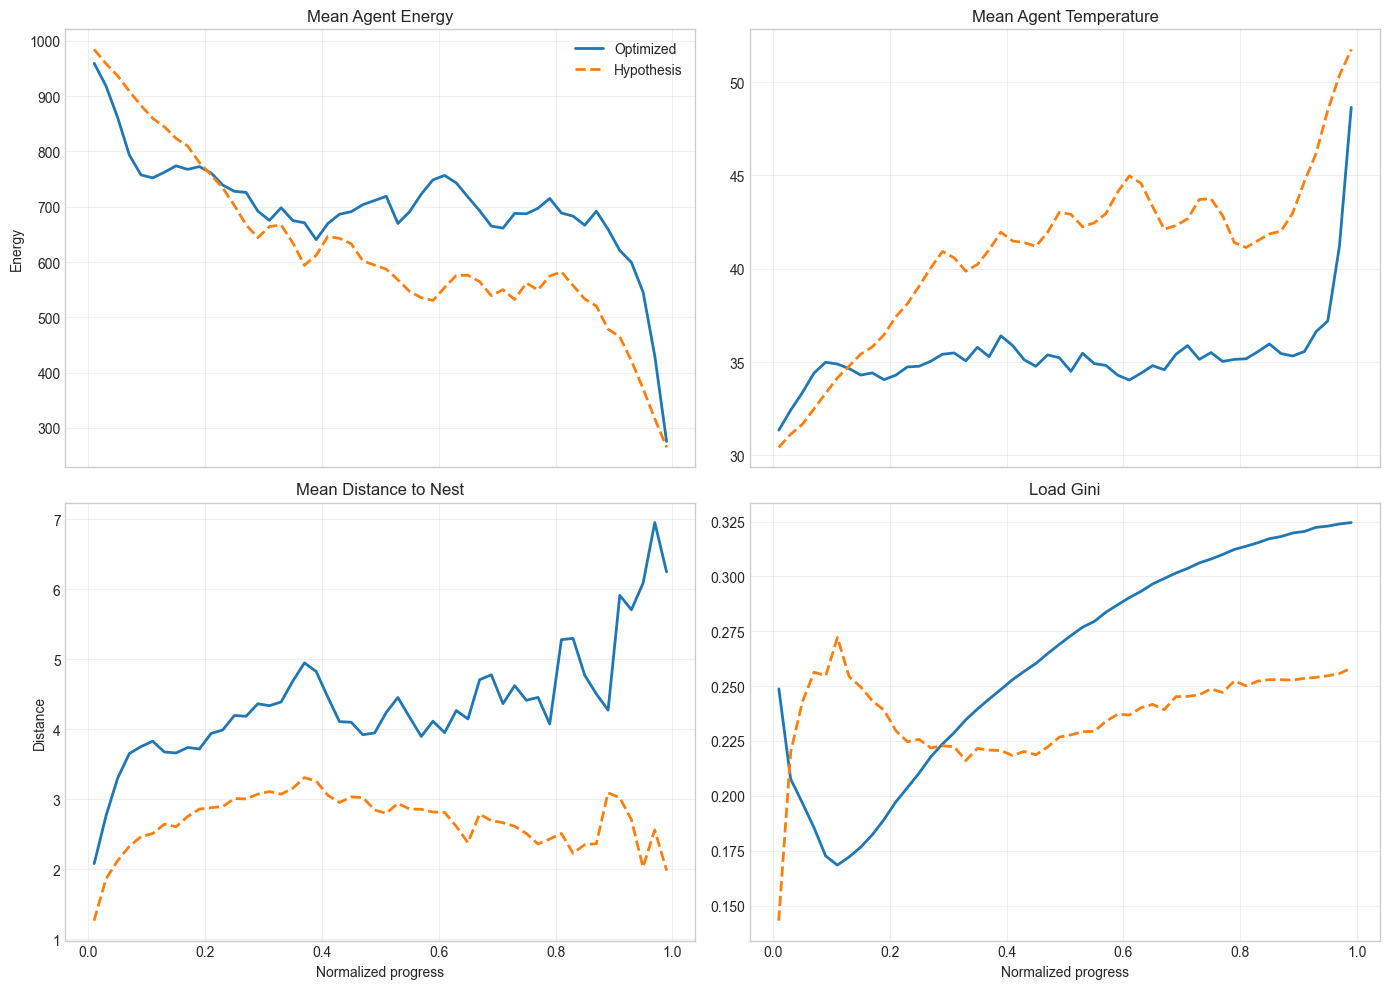

In [27]:
def process_energy_heat_fairness(df, dataset_name):
    print(f"\n--- Energy, Heat, and Fairness: {dataset_name} ---")
    
    step_summary = (
        df.groupby(["RunId", "Step"], as_index=False)
        .agg(
            total_food_collected=("Total Food Collected", "first"),
            mean_agent_energy=("Energy", "mean"),
            mean_agent_temperature=("Temperature", "mean"),
            mean_distance_to_nest=("Distance_to_Nest", "mean"),
            load_gini=("Load Gini", "first"),
            thermal_efficiency=("Thermal Efficiency", "first"),
        )
        .sort_values(["RunId", "Step"])
        .reset_index(drop=True)
    )
    
    step_summary["normalized_progress"] = step_summary["Step"] / step_summary.groupby("RunId")["Step"].transform("max")
    
    step_summary["phase"] = pd.cut(
        step_summary["normalized_progress"],
        bins=np.linspace(0.0, 1.0, 6),
        labels=["0-20%", "20-40%", "40-60%", "60-80%", "80-100%"],
        include_lowest=True,
    )
    
    progress_bins = np.linspace(0.0, 1.0, 51)
    step_summary["progress_bin"] = pd.cut(step_summary["normalized_progress"], bins=progress_bins, labels=False, include_lowest=True)

    phase_means = (
        step_summary.groupby("phase", observed=False)
        .agg(
            mean_agent_energy=("mean_agent_energy", "mean"),
            mean_agent_temperature=("mean_agent_temperature", "mean"),
            load_gini=("load_gini", "mean")
        )
        .reset_index()
    )

    print(f"- Mean agent energy at 0-20%: {phase_means.loc[phase_means['phase'] == '0-20%', 'mean_agent_energy'].iloc[0]:.2f}")
    print(f"- Mean agent energy at 80-100%: {phase_means.loc[phase_means['phase'] == '80-100%', 'mean_agent_energy'].iloc[0]:.2f}")
    print(f"- Mean temperature at 0-20%: {phase_means.loc[phase_means['phase'] == '0-20%', 'mean_agent_temperature'].iloc[0]:.2f}")
    print(f"- Mean temperature at 80-100%: {phase_means.loc[phase_means['phase'] == '80-100%', 'mean_agent_temperature'].iloc[0]:.2f}")
    print(f"- Load Gini at 0-20%: {phase_means.loc[phase_means['phase'] == '0-20%', 'load_gini'].iloc[0]:.3f}")
    print(f"- Load Gini at 80-100%: {phase_means.loc[phase_means['phase'] == '80-100%', 'load_gini'].iloc[0]:.3f}")

    energy_curves = (
        step_summary.dropna(subset=["progress_bin"])
        .groupby("progress_bin", observed=True)
        .agg(
            progress_center=("normalized_progress", "mean"),
            mean_agent_energy=("mean_agent_energy", "mean"),
            mean_agent_temperature=("mean_agent_temperature", "mean"),
            mean_distance_to_nest=("mean_distance_to_nest", "mean"),
            load_gini=("load_gini", "mean"),
            thermal_efficiency=("thermal_efficiency", "mean"),
        )
        .reset_index(drop=True)
    )

    energy_temperature_run_summary = (
        step_summary.groupby("RunId", as_index=False)
        .agg(
            completed_steps=("Step", "max"),
            final_total_food_collected=("total_food_collected", "last"),
            final_mean_temperature=("mean_agent_temperature", "last"),
            final_load_gini=("load_gini", "last"),
            final_thermal_efficiency=("thermal_efficiency", "last"),
        )
    )
    
    print("\nFinal Run State Summary (Cleaned):")
    display(energy_temperature_run_summary.drop(columns=["RunId"]).describe().T)
    
    return energy_curves

curves_opt = process_energy_heat_fairness(optimized, "Optimized")
curves_hyp = process_energy_heat_fairness(hypothesis, "Hypothesis")


fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

# Mean Agent Energy
axes[0, 0].plot(curves_opt["progress_center"], curves_opt["mean_agent_energy"], color="#1f77b4", linewidth=2, label="Optimized")
axes[0, 0].plot(curves_hyp["progress_center"], curves_hyp["mean_agent_energy"], color="#ff7f0e", linewidth=2, linestyle="--", label="Hypothesis")
axes[0, 0].set_title("Mean Agent Energy")
axes[0, 0].set_ylabel("Energy")
axes[0, 0].legend()

# Mean Agent Temperature
axes[0, 1].plot(curves_opt["progress_center"], curves_opt["mean_agent_temperature"], color="#1f77b4", linewidth=2)
axes[0, 1].plot(curves_hyp["progress_center"], curves_hyp["mean_agent_temperature"], color="#ff7f0e", linewidth=2, linestyle="--")
axes[0, 1].set_title("Mean Agent Temperature")

# Mean Distance to Nest
axes[1, 0].plot(curves_opt["progress_center"], curves_opt["mean_distance_to_nest"], color="#1f77b4", linewidth=2)
axes[1, 0].plot(curves_hyp["progress_center"], curves_hyp["mean_distance_to_nest"], color="#ff7f0e", linewidth=2, linestyle="--")
axes[1, 0].set_title("Mean Distance to Nest")
axes[1, 0].set_xlabel("Normalized progress")
axes[1, 0].set_ylabel("Distance")

# Load Gini
axes[1, 1].plot(curves_opt["progress_center"], curves_opt["load_gini"], color="#1f77b4", linewidth=2)
axes[1, 1].plot(curves_hyp["progress_center"], curves_hyp["load_gini"], color="#ff7f0e", linewidth=2, linestyle="--")
axes[1, 1].set_title("Load Gini")
axes[1, 1].set_xlabel("Normalized progress")

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The physiological progression of the agents further highlights the systemic sustainability of the Optimized configuration. While both groups exhibit similar energy and temperature baselines during the initial 0-20% phase, their trajectories rapidly diverge. The Hypothesis group experiences severe thermal escalation, with mean temperatures aggressively climbing to 45.07°C by the final progression phase (80-100%), causing their energy reserves to simultaneously crash to an average of 451.84. In contrast, the Optimized swarm demonstrates remarkable thermoregulation, maintaining a highly stable mean temperature between 34°C and 37°C for the vast majority of its lifespan before a final terminal spike. By successfully mitigating heat generation, the Optimized agents preserve significantly more energy in their late stages (586.59), delaying the onset of critical metabolic failure.

This physiological stability directly translates into superior spatial exploitation, as evidenced by the Mean Distance to Nest metric. Because the Hypothesis agents quickly push themselves to the edge of their thermal limits ($T_{crit}$), they become physically constrained to the immediate vicinity of the nest, hovering around a mean distance of merely 2 to 3 cells throughout their entire run. The Optimized agents, protected from acute thermal distress by their calibrated foraging thresholds and resting phases, exhibit a steady outward spatial expansion. By the end of their runs, they push their mean foraging radius to nearly 7 cells. This proves that the Optuna-tuned safety buffers actively empower the swarm to harvest and safely return from deeper, more distant food clusters that are practically inaccessible to the overheating baseline group.

Finally, the progression of the Load Gini coefficient recontextualizes how workload inequality functions within a surviving swarm. The Hypothesis group maintains a relatively flat and seemingly equitable Gini curve, stabilizing around 0.254. However, this is largely an artifact of premature mortality with the agents simply do not survive long enough to accumulate disproportionate lifetime collection totals. Conversely, the Optimized group’s Gini steadily rises from 0.190 to 0.320 across its lifecycle. Rather than indicating a mechanical failure in task sharing, this upward trend reflects the successful emergence of "veteran" foragers—agents that survive multiple treacherous trips to distant clusters and accrue massive individual collection tallies. In the context of extended swarm longevity, this increasing inequality is a positive indicator of robust pheromone trail exploitation and sustained individual survivability.

## 5. Agent-Level Work Distribution

--- Agent-Level Work Distribution: Optimized ---
- Fraction of agents that collected no food: 5.0%
- Mean food collected per agent: 18.96
- Median food collected per agent: 14.00
- Share of all collected food handled by the top 10% of agents: 32.3%



,count,mean,std,min,25%,50%,75%,90%,95%,max
Lifetime Food Collected,1200.0,18.956667,18.717017,0.0,6.0,14.0,25.0,42.0,55.05,188.0




--- Agent-Level Work Distribution: Hypothesis ---
- Fraction of agents that collected no food: 12.3%
- Mean food collected per agent: 6.53
- Median food collected per agent: 4.00
- Share of all collected food handled by the top 10% of agents: 37.8%



,count,mean,std,min,25%,50%,75%,90%,95%,max
Lifetime Food Collected,1500.0,6.529333,7.744318,0.0,1.0,4.0,9.0,16.0,23.0,70.0


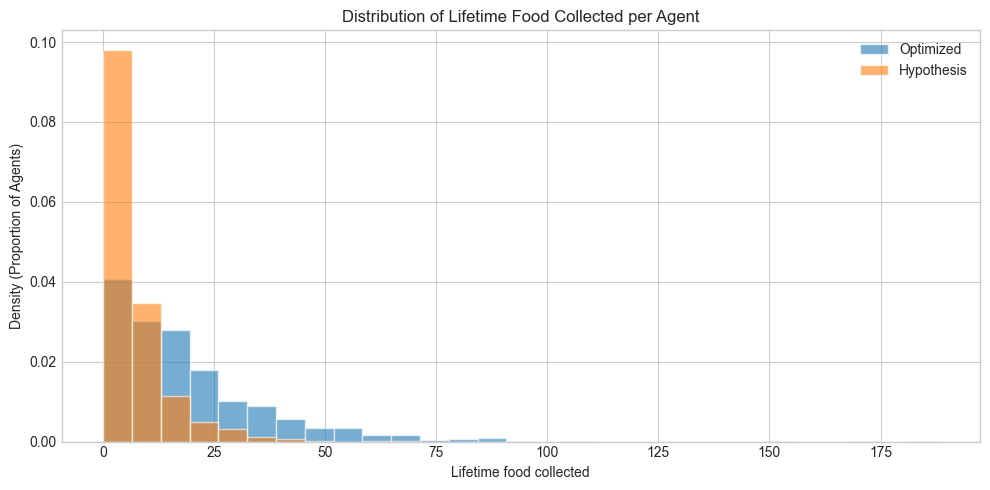

In [28]:
def analyze_work_distribution(df, dataset_name):
    print(f"--- Agent-Level Work Distribution: {dataset_name} ---")

    agent_last_index = df.groupby(["RunId", "AgentID"])['Step'].idxmax()
    last_agent_rows = df.loc[agent_last_index].copy().reset_index(drop=True)


    agent_food = last_agent_rows["Lifetime Food Collected"].fillna(0).astype(float)

    food_summary = agent_food.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).to_frame().T
    food_summary.index = ["Lifetime Food Collected"]

    zero_food_fraction = float((agent_food <= 0).mean())

    food_sorted = np.sort(agent_food.to_numpy())
    if food_sorted.sum() > 0:
        top_10_start = int(np.floor(0.9 * len(food_sorted)))
        top_10_share = float(food_sorted[top_10_start:].sum() / food_sorted.sum())
    else:
        top_10_share = 0.0

    print(f"- Fraction of agents that collected no food: {zero_food_fraction:.1%}")
    print(f"- Mean food collected per agent: {agent_food.mean():.2f}")
    print(f"- Median food collected per agent: {agent_food.median():.2f}")
    print(f"- Share of all collected food handled by the top 10% of agents: {top_10_share:.1%}")
    print()
    display(food_summary)
    print("\n" + "="*50 + "\n")

    return agent_food

food_opt = analyze_work_distribution(optimized, "Optimized")
food_hyp = analyze_work_distribution(hypothesis, "Hypothesis")

fig, ax = plt.subplots(figsize=(10, 5))

min_food = min(food_opt.min(), food_hyp.min())
max_food = max(food_opt.max(), food_hyp.max())
shared_bins = np.linspace(min_food, max_food, 30) 

ax.hist(food_opt, bins=shared_bins, alpha=0.6, label="Optimized", density=True, color="#1f77b4", edgecolor="white")
ax.hist(food_hyp, bins=shared_bins, alpha=0.6, label="Hypothesis", density=True, color="#ff7f0e", edgecolor="white")

ax.set_title("Distribution of Lifetime Food Collected per Agent")
ax.set_xlabel("Lifetime food collected")
ax.set_ylabel("Density (Proportion of Agents)")
ax.legend()

plt.tight_layout()
plt.show()

--- Agent-Level Radial Movement: Optimized ---
- Mean radial distance per agent: 528.7
- Median radial distance per agent: 420.5
- Share of all radial movement done by the top 10% of agents: 27.3%



,count,mean,std,min,25%,50%,75%,90%,95%,max
Lifetime Radial Distance,1200.0,528.676667,413.618519,92.0,281.75,420.5,676.5,946.2,1220.15,4210.0




--- Agent-Level Radial Movement: Hypothesis ---
- Mean radial distance per agent: 236.8
- Median radial distance per agent: 206.0
- Share of all radial movement done by the top 10% of agents: 21.8%



,count,mean,std,min,25%,50%,75%,90%,95%,max
Lifetime Radial Distance,1500.0,236.837333,128.804775,86.0,150.0,206.0,280.0,386.0,442.2,1588.0


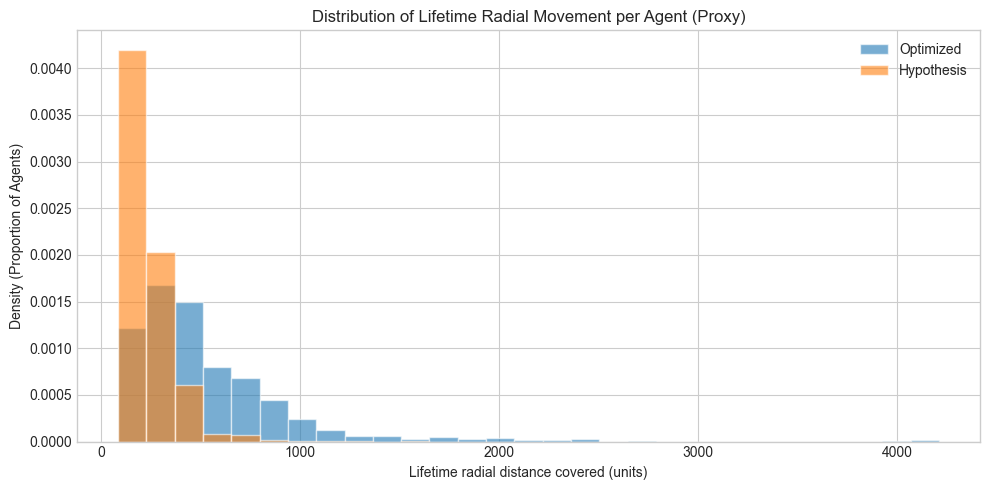

In [29]:
def analyze_radial_distance(df, dataset_name):
    print(f"--- Agent-Level Radial Movement: {dataset_name} ---")
    df_sorted = df.sort_values(["RunId", "AgentID", "Step"]).copy()
    df_sorted["step_radial_dist"] = df_sorted.groupby(["RunId", "AgentID"])["Distance_to_Nest"].diff().abs().fillna(0)

    agent_radial_distance = df_sorted.groupby(["RunId", "AgentID"])["step_radial_dist"].sum()

    dist_summary = agent_radial_distance.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).to_frame().T
    dist_summary.index = ["Lifetime Radial Distance"]

    dist_sorted = np.sort(agent_radial_distance.to_numpy())
    if dist_sorted.sum() > 0:
        top_10_start = int(np.floor(0.9 * len(dist_sorted)))
        top_10_share = float(dist_sorted[top_10_start:].sum() / dist_sorted.sum())
    else:
        top_10_share = 0.0

    print(f"- Mean radial distance per agent: {agent_radial_distance.mean():,.1f}")
    print(f"- Median radial distance per agent: {agent_radial_distance.median():,.1f}")
    print(f"- Share of all radial movement done by the top 10% of agents: {top_10_share:.1%}")
    print()
    display(dist_summary)
    print("\n" + "="*50 + "\n")

    return agent_radial_distance

dist_opt = analyze_radial_distance(optimized, "Optimized")
dist_hyp = analyze_radial_distance(hypothesis, "Hypothesis")


fig, ax = plt.subplots(figsize=(10, 5))

min_dist = min(dist_opt.min(), dist_hyp.min())
max_dist = max(dist_opt.max(), dist_hyp.max())
shared_bins = np.linspace(min_dist, max_dist, 30)

# Overlaid histograms
ax.hist(dist_opt, bins=shared_bins, alpha=0.6, label="Optimized", density=True, color="#1f77b4", edgecolor="white")
ax.hist(dist_hyp, bins=shared_bins, alpha=0.6, label="Hypothesis", density=True, color="#ff7f0e", edgecolor="white")

ax.set_title("Distribution of Lifetime Radial Movement per Agent (Proxy)")
ax.set_xlabel("Lifetime radial distance covered (units)")
ax.set_ylabel("Density (Proportion of Agents)")
ax.legend()

plt.tight_layout()
plt.show()

The agent-level distributions demonstrate, that the Optimized configuration successfully translates individual longevity into universally higher productivity. The Optimized swarm collects nearly three times more food per agent (18.96 versus 6.53) while dramatically reducing the fraction of entirely ineffective foragers—only 5.0% of Optimized agents collected zero food, compared to 12.3% in the Hypothesis group. The lifetime food density plot clearly illustrates this shift: the Hypothesis distribution is overwhelmingly dominated by early failures, whereas the Optimized group develops a broad "middle class" of successful foragers alongside a pronounced tail of high-performing veterans. Notably, despite producing individual veterans that collect massive quantities (up to 188 units), the top 10% of Optimized agents handle a smaller overall share of the total workload (32.3% versus 37.8%). This indicates that the Optuna-tuned parameters foster a more uniformly capable swarm, rather than one reliant on a few lucky outliers.

This superior collection capacity is mechanically driven by the agents' vastly expanded lifetime spatial mobility. Because the Optimized parameters effectively mitigate systemic thermal constraints, agents survive long enough to travel more than twice the radial distance of their Hypothesis counterparts (a mean of 528.7 units versus 236.8). The aggressive, early-burn strategy of the Hypothesis configuration severely stunts lifetime mobility, preventing agents from compounding their exploratory efforts. Ultimately, by securing the survival of agents through multiple extended foraging loops, the optimized safety buffers physically empower the swarm to push deeper into the environment, securing the distant resources necessary for sustainable systemic success.

## Conclusion

The comparative analysis between the Hypothesis and Optimized configurations reveals a fundamental paradigm shift in swarm survival strategy. The Hypothesis parameters drove an aggressive, high-intensity exploitation model that maximized short-term retrieval rates but critically failed to manage the environment's physiological constraints. By keeping agents in the field until the absolute limits of their thermal capacity, the Hypothesis swarm fell victim to the "Returning Death Trap," experiencing rapid, catastrophic population collapse due to heatstroke. While early metrics appeared promising, the swarm simply burned too fast and too bright to sustain long-term operations.

Conversely, the Optuna-tuned configuration demonstrated that in environments governed by severe physical limitations, systemic pacing is vastly superior to peak efficiency. By enforcing larger safety margins, raising foraging energy thresholds, and maintaining a consistent resting population as a vital thermal sink, the Optimized swarm successfully neutralized acute heat death. This strategic pacing allowed agents to survive more than twice as long, travel significantly further, and compound their exploratory efforts. Instead of dying on their first return trip, agents survived multiple foraging loops, giving rise to a highly productive "veteran" class that secured nearly double the total resources.

Ultimately, the optimization process did not eliminate mortality, but it transformed it. It shifted the swarm’s primary failure mode from premature thermal collapse to eventual, unavoidable metabolic exhaustion. By stretching the operational limits of individual agents and prioritizing thermal regulation over immediate collection, the Optimized configuration provides a definitive blueprint for resilient, long-term swarm foraging under extreme environmental stress.